<a href="https://colab.research.google.com/github/seokjinwoo/AiandEcon_2026/blob/main/lec_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
## deep learning
## Titanic data
## predicting who will survive the accident

## library loading
import pandas as pd, numpy as np
import tensorflow as tf # deep learning 을 위한 library
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [14]:
## loading titanic data from seaborn
import seaborn as sns

df = sns.load_dataset('titanic')
# df.head()
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']].copy()

In [17]:
## 간단한 전처리

# 결측치를 median 값으로
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [19]:
# 원-핫 인코딩 & 표준화
df = pd.get_dummies(df, columns=['sex','embarked'], drop_first=True)

X = df.drop('survived', axis=1).values
y = df['survived']

scaler = StandardScaler()
X = scaler.fit_transform(X)



In [22]:
# train & validationi data split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)




In [24]:
## deep learning 을 위한 MLP 모형 정의

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'), # 은닉층 1
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'), # 은닉층 2
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid') # 이진 분류 출력
])

In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
## 학습 (early stopping rule을 적용)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)





Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8329 - loss: 0.4173 - val_accuracy: 0.8212 - val_loss: 0.4133
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8315 - loss: 0.4027 - val_accuracy: 0.8212 - val_loss: 0.4161
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8287 - loss: 0.3980 - val_accuracy: 0.8212 - val_loss: 0.4189
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8287 - loss: 0.4139 - val_accuracy: 0.8212 - val_loss: 0.4232
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8287 - loss: 0.4177 - val_accuracy: 0.8212 - val_loss: 0.4244
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8455 - loss: 0.4020 - val_accuracy: 0.8212 - val_loss: 0.4244
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8357 - loss: 0.3929 - val_accuracy: 0.8212 - val_loss: 0.4322
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8469 - loss: 0.3915 - val_accuracy: 0.8268 - v

In [43]:
## 성능평가
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

loss, acc = model.evaluate(X_val, y_val)
print(f'Validation Accuracy: {acc*100:.2f}%')
y_pre = (model.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_pre, target_names=['Not Survived', 'Survived']))



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8212 - loss: 0.4133 
Validation Accuracy: 82.12%
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

Not Survived       0.81      0.90      0.86       105
    Survived       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



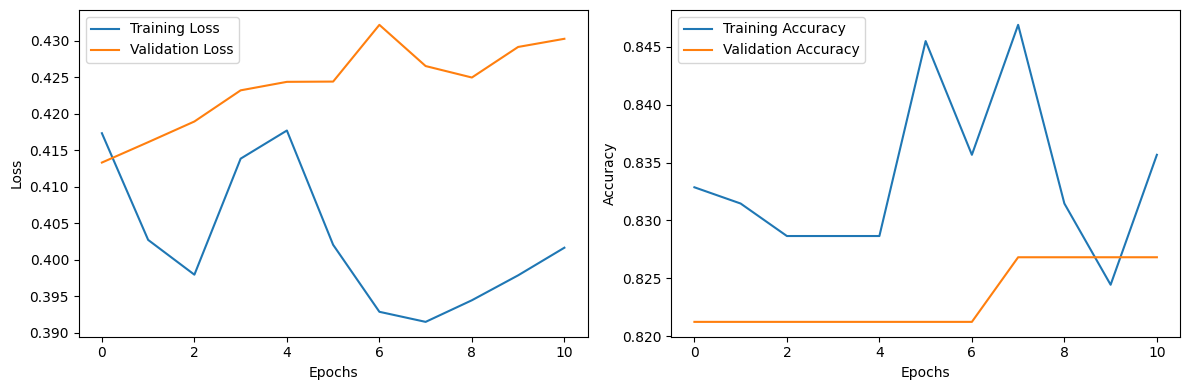

In [45]:
## 학습 곡선
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()

plt.show()

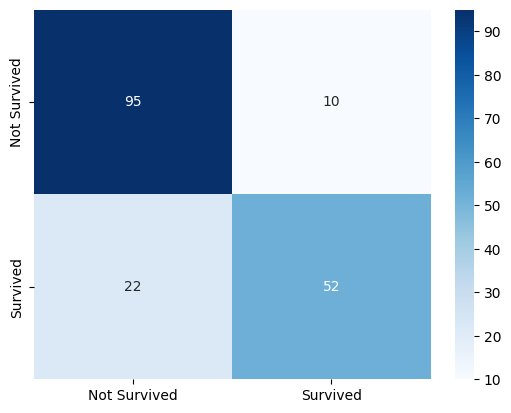

In [46]:
## 혼동행렬

import seaborn as sns
cm = confusion_matrix(y_val, y_pre)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])

plt.show()

